# Notebook: Portfolio Insurance

คำอธิบายและสมการต่อไปนี้มาจากบทเรียนเดียวกับเว็บไซต์ **Portfolio Management Toolkit** ใช้ Python 3 และ standard library สำหรับคำนวณ เลือก **Run All** ได้โดยไม่ต้องดาวน์โหลดข้อมูลหรือติดตั้งแพ็กเกจคำนวณ กราฟ SVG ฝังอยู่ในไฟล์และใช้ IPython เพื่อแสดงผลเมื่อมีให้ใช้

เซลล์ตั้งต้นเก็บฟังก์ชันร่วม ส่วนเซลล์ทดลองอยู่ถัดจากเนื้อหาที่เกี่ยวข้อง ปรับค่าตัวแปรแล้วรันตามลำดับ ตัวเลขทั้งหมดในห้องทดลองเป็นตัวอย่างสมมติ ไม่ใช่ข้อมูลตลาดหรือการทำซ้ำวิทยานิพนธ์

ลิงก์ไปหน้าอื่นใช้ไฟล์ในชุดเว็บไซต์ที่อยู่ระดับเหนือโฟลเดอร์ `notebooks/`; การคำนวณใน Notebook ทำงานได้แม้แยกไฟล์นี้ออกมา

In [1]:
import csv
import html
import io
import math

# The same illustrative monthly paths as the website, copied into this file.
SCENARIOS = {
    "rally": [
        0.03,
        0.02,
        0.04,
        0.01,
        0.035,
        0.02,
        0.03,
        -0.01,
        0.04,
        0.02,
        0.03,
        0.015
    ],
    "crash": [
        0.03,
        0.02,
        0.04,
        -0.4,
        0.08,
        0.06,
        0.05,
        0.04,
        0.06,
        0.03,
        0.04,
        0.03
    ],
    "whipsaw": [
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1,
        0.12,
        -0.1
    ],
    "recovery": [
        -0.12,
        -0.08,
        -0.1,
        0.15,
        0.12,
        0.1,
        0.08,
        0.06,
        0.05,
        0.04,
        0.03,
        0.02
    ]
}

def close(actual, expected, tolerance=1e-9):
    assert math.isclose(actual, expected, rel_tol=tolerance, abs_tol=tolerance), (actual, expected)

def number_in_range(name, value, minimum, maximum=math.inf, exclusive=False):
    if (isinstance(value, bool) or not isinstance(value, (int, float))
            or not math.isfinite(value) or value > maximum
            or (value <= minimum if exclusive else value < minimum)):
        raise ValueError(f"Invalid {name}: {value!r}")

def allocate(value, floor, multiplier):
    cushion = value - floor
    exposure = min(value, max(0, multiplier * cushion))
    return dict(cushion=cushion, exposure=exposure, safe=value-exposure,
                weight=exposure/value if value > 0 else 0)

def calculate_allocation(initial=100, floor_pct=90, multiplier=3):
    number_in_range("initial", initial, 0, exclusive=True)
    number_in_range("floor_pct", floor_pct, 0, 100)
    number_in_range("multiplier", multiplier, 0)
    return allocate(initial, initial * (floor_pct / 100), multiplier)

def summarize(rows, key, initial):
    peak, drawdown = initial, 0
    for row in rows:
        peak = max(peak, row[key])
        drawdown = max(drawdown, 100 * (peak-row[key]) / peak)
    final = rows[-1][key]
    return dict(final=final, returnPct=(final/initial-1)*100,
                maxDrawdownPct=drawdown, minValue=min(row[key] for row in rows))

def simulate(initial=100, floor_pct=90, multiplier=3, scenario="crash", rate=0, returns=None):
    """One year; rebalance at 0 and after months 1–11, using observed values only.

    rate: annual continuously compounded decimal, supported from -1 to +1.
    floor_pct: terminal floor as a percentage of initial wealth.
    exposure in row 12: illustrative target only; no maturity trade is counted.
    """
    calculate_allocation(initial, floor_pct, multiplier)  # Validate inputs.
    number_in_range("rate", rate, -1, 1)
    if returns is None and scenario not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario}")
    path = SCENARIOS[scenario][:] if returns is None else list(returns)
    if len(path) != 12:
        raise ValueError("Exactly 12 monthly returns are required.")
    for monthly_return in path:
        number_in_range("monthly return", monthly_return, -1)
    terminal_floor = initial * (floor_pct / 100)
    floor_at = lambda month: terminal_floor * math.exp(-rate * (1-month/12))
    safe_growth = math.exp(rate/12)
    cppi = buy_hold = constant_mix = initial
    asset = 100
    allocation = allocate(cppi, floor_at(0), multiplier)
    rows = [dict(month=0, asset=asset, cppi=cppi, buyHold=buy_hold,
                 constantMix=constant_mix, floor=floor_at(0), **allocation,
                 riskyReturn=None, turnover=0)]
    total_turnover = 0
    for month, monthly_return in enumerate(path, start=1):
        held_risky = allocation["exposure"] * (1+monthly_return)
        cppi = held_risky + allocation["safe"] * safe_growth
        asset *= 1+monthly_return
        buy_hold *= 1+monthly_return
        constant_mix *= 0.60 * (1+monthly_return) + 0.40 * safe_growth
        floor = floor_at(month)
        allocation = allocate(cppi, floor, multiplier)
        turnover = abs(allocation["exposure"]-held_risky) if month < 12 else 0
        total_turnover += turnover
        row = dict(month=month, asset=asset, cppi=cppi, buyHold=buy_hold,
                   constantMix=constant_mix, floor=floor, **allocation,
                   riskyReturn=monthly_return, turnover=turnover)
        if not all(math.isfinite(v) for v in row.values() if isinstance(v, (int, float))):
            raise ValueError("Inputs exceed the supported numerical range.")
        rows.append(row)
    metrics = summarize(rows, "cppi", initial)
    metrics.update(floorBreached=any(row["cppi"] < row["floor"]-initial*1e-10 for row in rows),
                   totalTurnover=total_turnover,
                   locked=multiplier > 0 and any(row["cushion"] <= 0 for row in rows[:-1]))
    return dict(rows=rows, metrics=metrics,
                benchmarkMetrics={key: summarize(rows, key, initial) for key in ("buyHold", "constantMix")},
                parameters=dict(initial=initial, floorPct=floor_pct, multiplier=multiplier,
                                rate=rate, scenario=scenario if returns is None else "custom", months=12))

def protective_put(spot=100, strike=90, premium=4, terminal=80, quantity=1):
    """Stock plus a matching European put held to expiry; no dividends or costs.

    The supplied premium is an assumption, not an option-pricing model.
    """
    for name, value in (("spot", spot), ("quantity", quantity)):
        number_in_range(name, value, 0, exclusive=True)
    for name, value in (("strike", strike), ("premium", premium), ("terminal", terminal)):
        number_in_range(name, value, 0)
    stock_terminal = quantity * terminal
    payoff = quantity * max(strike-terminal, 0)
    wealth = stock_terminal + payoff
    cost = quantity * (spot+premium)
    profit = wealth-cost
    result = dict(stockTerminal=stock_terminal, putPayoff=payoff, terminalWealth=wealth,
                  initialCost=cost, profit=profit, returnPct=profit/cost*100)
    if not all(math.isfinite(v) for v in result.values()):
        raise ValueError("Inputs exceed the supported numerical range.")
    return result

def cppi_csv(result):
    """Return CSV text without writing a file or sending any data anywhere."""
    out = io.StringIO(newline="")
    writer = csv.writer(out)
    names = ["month", "riskyReturn", "asset", "cppi", "buyHold", "constantMix",
             "floor", "exposure", "cushion", "safe", "turnover"]
    parameters = result["parameters"]
    writer.writerow([*parameters, *names])
    for row in result["rows"]:
        writer.writerow([*parameters.values(), *(row[name] for name in names)])
    return out.getvalue()

print("Python standard library models ready. All paths are illustrative, not market data.")
print("No borrowing, no shorting, fractional units allowed; monthly observations; zero trading costs.")

Python standard library models ready. All paths are illustrative, not market data.
No borrowing, no shorting, fractional units allowed; monthly observations; zero trading costs.


In [2]:
def chart_svg(rows, series, x_key="month", title="CPPI experiment", x_label="Month"):
    """Render observed values as SVG; lines connect observations, not hidden data."""
    width, height = 800, 420
    left, right, top, bottom = 66, 24, 64, 108
    values = [row[key] for row in rows for key, label, color, dash in series]
    lo = math.floor((min(values)-5)/10)*10
    hi = math.ceil((max(values)+5)/10)*10
    xs = [row[x_key] for row in rows]
    x = lambda value: left+(value-min(xs))/(max(xs)-min(xs))*(width-left-right)
    y = lambda value: top+(hi-value)/(hi-lo)*(height-top-bottom)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="800" height="420" viewBox="0 0 800 420" role="img" aria-label="{html.escape(title)}">',
             f'<title>{html.escape(title)}</title>',
             '<rect width="800" height="420" fill="#FFFFFF"/>',
             '<g font-family="Roboto, Arial, sans-serif" fill="#212121">',
             f'<text x="{left}" y="26" font-size="20" font-weight="600">{html.escape(title)}</text>',
             f'<text x="{left}" y="48" font-size="13">Value in units · {len(rows)} observations · illustrative only</text>']
    for index in range(5):
        value = lo+(hi-lo)*index/4
        parts.append(f'<line x1="{left}" x2="{width-right}" y1="{y(value):.3f}" y2="{y(value):.3f}" stroke="#DEDEDE"/>')
        parts.append(f'<text x="{left-12}" y="{y(value)+5:.3f}" font-size="14" text-anchor="end">{value:g}</text>')
    for index in (0, len(rows)//3, 2*len(rows)//3, len(rows)-1):
        value = xs[index]
        parts.append(f'<text x="{x(value):.3f}" y="{height-bottom+25}" font-size="14" text-anchor="middle">{value:g}</text>')
    for key, label, color, dash in series:
        points = " ".join(f'{x(row[x_key]):.3f},{y(row[key]):.3f}' for row in rows)
        parts.append(f'<polyline points="{points}" fill="none" stroke="{color}" stroke-width="2.8" stroke-dasharray="{dash}"/>')
    parts.append(f'<text x="{width-right}" y="{height-bottom+47}" font-size="14" text-anchor="end">{html.escape(x_label)}</text>')
    for index, (key, label, color, dash) in enumerate(series):
        column, row = index % 2, index // 2
        lx, ly = left+column*345, height-40+row*24
        parts.append(f'<line x1="{lx}" x2="{lx+30}" y1="{ly-4}" y2="{ly-4}" stroke="{color}" stroke-width="3" stroke-dasharray="{dash}"/>')
        parts.append(f'<text x="{lx+40}" y="{ly}" font-size="14">{html.escape(label)}</text>')
    return "".join(parts)+"</g></svg>"

def show_svg(svg):
    # The generator captures rich output; an ordinary notebook uses IPython.
    capture = globals().get("_portfolio_svg_capture")
    if capture is not None:
        capture(svg)
        return
    try:
        from IPython.display import SVG, display
    except ImportError:
        print("SVG chart available in the returned string; numerical tables are shown below.")
    else:
        display(SVG(svg))

CPPI_SERIES = [("cppi", "CPPI", "#6200EE", ""),
               ("buyHold", "Buy & hold (100% risky)", "#008577", "8 5"),
               ("constantMix", "Constant mix (60/40)", "#555555", "2 4"),
               ("floor", "Target floor", "#B00020", "6 4")]
print("Deterministic SVG charts ready; no image or chart service is called.")

Deterministic SVG charts ready; no image or chart service is called.


# Portfolio Insurance Strategies: Friend or Foe?

ถ้าอยากให้พอร์ตเติบโต แต่ไม่อยากให้มูลค่าลดลงเกินระดับหนึ่ง เราต้องแลกอะไรบ้าง

สมมติว่าเรามีเงินลงทุน 100 หน่วย อยากรับการเติบโตจากสินทรัพย์เสี่ยง แต่ก็อยากเหลือเงินอย่างน้อย 90 หน่วยเมื่อครบหนึ่งปี คำถามดูเหมือนจะเป็นเพียง “ควรถือหุ้นเท่าไร” แต่มีรายละเอียดซ่อนอยู่หลายข้อ หากหุ้นลง เราจะขายเมื่อไร ถ้าราคาข้ามจุดที่ตั้งใจขายจะทำอย่างไร และถ้าตลาดกลับขึ้นหลังจากขายไปแล้ว เราจะยังมีส่วนร่วมกับการฟื้นตัวหรือไม่

**[Portfolio Insurance](../glossary.html#portfolio-insurance)** เป็นกลุ่มกลยุทธ์ที่พยายามตอบคำถามเหล่านี้ บางแบบซื้อสิทธิผ่าน Option บางแบบใช้กฎย้ายเงินระหว่างสินทรัพย์เสี่ยงกับสินทรัพย์ปลอดความเสี่ยง แต่ละแบบจึงมีทั้งต้นทุนและเงื่อนไขที่ทำให้การป้องกันทำงานได้

บทนี้เรียบเรียงใหม่จากวิทยานิพนธ์ *Portfolio Insurance Strategies: Friend or Foe?* ของ **Paulo José Martins Jorge da Silva (2018)** เราจะเริ่มจากกลไกที่คำนวณตามได้ แล้วค่อยอ่านผลวิจัยเรื่องความชอบของผู้ลงทุนและการประเมินความเสี่ยงผ่าน Robo-advisors [ข้อมูลต้นฉบับและเลขหน้า](#references)

**สิ่งที่จะได้จากบทนี้**

แยก Payoff ออกจากกำไร · จัดงบซื้อการป้องกัน · คำนวณ Floor, Cushion และเงินลงทุนเสี่ยงของ CPPI · อธิบาย Gap risk และ Cash lock · เปรียบเทียบ CPPI กับ TIPP · อ่านผลวิจัย EUT/CPT ภายใต้สมมติฐานที่ใช้

ตัวเลขที่ใช้สอนและเครื่องมือในหน้าเป็น **ตัวอย่างสมมติ** หน่วยเงินเป็นหน่วยทั่วไป ไม่ใช่ราคาตลาดจริง ตัวอย่าง CPPI เริ่มด้วยพอร์ต 100, Floor 90, Multiplier 3 และดอกเบี้ย 0% ส่วนตัวอย่างหุ้นหนึ่งหน่วยบวก Put จะมีต้นทุนรวม **104 หน่วย** ซึ่งเราจะแยกให้ชัดก่อนเปรียบเทียบพอร์ต

<a id="floor-and-cushion"></a>

## 1. ก่อนป้องกัน ต้องรู้ว่าปกป้องเท่าไรและเมื่อไร

ประโยคว่า “อยากรักษาเงินไว้ 90 หน่วย” ยังไม่ครบ เราต้องบอกด้วยว่า **ณ เวลาใด** การต้องการให้พอร์ตมีอย่างน้อย 90 หน่วยเมื่อครบหนึ่งปี ต่างจากการไม่ยอมให้พอร์ตต่ำกว่า 90 หน่วยในวันใดเลย และทั้งสองแบบต่างจากการจำกัดการลดลงนับจากจุดสูงสุดของพอร์ต

ระดับมูลค่าที่มุ่งป้องกันเรียกว่า **[Floor](../glossary.html#floor)** ให้ $F_T$ เป็น Floor เมื่อครบกำหนด $T$ และ $F_t$ เป็นมูลค่าของเป้าหมายนี้ ณ เวลา $t$ ถ้าสามารถลงทุนในสินทรัพย์ปลอดความเสี่ยงที่ให้อัตราดอกเบี้ยทบต้นต่อเนื่อง $r$ ต่อปี จะได้

$$
F_t=F_Te^{-r(T-t)}.
$$

เงิน $F_t$ วันนี้จะโตเป็น $F_T$ ในเวลาที่เหลือ เมื่อ $r=0$ การคิดลดไม่มีผล Floor วันนี้จึงเท่ากับ Floor ปลายทาง แต่เมื่อดอกเบี้ยเป็นบวก เงินที่ต้องกันไว้วันนี้อาจน้อยกว่าเป้าหมายปลายทางได้

| สัญลักษณ์ | ความหมายและหน่วย |
|---|---|
| $V_t$ | มูลค่าพอร์ต ณ เวลา $t$ หน่วยเงิน |
| $F_T$ | มูลค่าขั้นต่ำที่ตั้งเป้าเมื่อครบกำหนด หน่วยเงิน |
| $F_t$ | มูลค่าปัจจุบันของ Floor ปลายทาง หน่วยเงิน |
| $r$ | อัตราดอกเบี้ยทบต้นต่อเนื่องต่อปี เขียนเป็นทศนิยม |
| $T-t$ | เวลาที่เหลือจนถึงวันครบกำหนด หน่วยปี |

พื้นฐานของการป้องกันหลายกลยุทธ์คือการกันเงินส่วนหนึ่งไว้รองรับเป้าหมาย แล้วใช้ส่วนที่เหลือรับโอกาสเติบโต แต่ “กันเงินไว้” อาจหมายถึงถือสินทรัพย์ปลอดความเสี่ยงจริง หรือเป็นเพียงเกณฑ์ในกฎปรับพอร์ต ซึ่งให้ความคุ้มครองต่างกัน

**Floor เป็นเป้าหมายของกลยุทธ์ ไม่ได้สร้างผู้รับประกันขึ้นมาโดยตัวมันเอง** การรักษาเป้าหมายได้จริงขึ้นกับสินทรัพย์ สัญญา สภาพคล่อง และเวลาที่ปรับพอร์ต แนวคิด Floor และกลยุทธ์ที่ใช้จะพบในบท 2 ของต้นฉบับ [พิมพ์ น. 9–16 / PDF 36–43](#references)

In [3]:
initial, terminal_floor, annual_rate = 100, 90, 0
for month in [0, 6, 12]:
    floor = terminal_floor * math.exp(-annual_rate*(1-month/12))
    print(f"Month {month:>2}: discounted floor={floor:.2f}")
print(f"Initial cushion={initial-terminal_floor*math.exp(-annual_rate):.2f}")

Month  0: discounted floor=90.00
Month  6: discounted floor=90.00
Month 12: discounted floor=90.00
Initial cushion=10.00


<a id="protective-put"></a>

## 2. เริ่มจากหุ้นหนึ่งหน่วยและสิทธิที่จะขาย

วิธีที่เห็นภาพตรงที่สุดคือถือสินทรัพย์เสี่ยงร่วมกับ **Put option** ซึ่งให้สิทธิขายสินทรัพย์อ้างอิงที่ราคาใช้สิทธิ $K$ ในตัวอย่างนี้ใช้ European Put: พิจารณาการใช้สิทธิเมื่อหมดอายุ และถือสินทรัพย์หนึ่งหน่วยกับ Put ที่อ้างอิงหนึ่งหน่วยพอดี

ให้ $S_T$ เป็นราคาสินทรัพย์เมื่อหมดอายุ Put มี [Payoff](../glossary.html#payoff) เท่ากับ

$$
P_T=\max(K-S_T,0).
$$

ถ้าราคาปลายทางต่ำกว่า $K$ Put จ่ายชดเชยส่วนต่าง ถ้าราคาสูงกว่า $K$ สิทธินี้ไม่มีมูลค่าเมื่อหมดอายุ เมื่อนำมารวมกับสินทรัพย์ที่ถืออยู่ มูลค่าปลายทางจึงเป็น

$$
S_T+P_T=S_T+\max(K-S_T,0)=\max(S_T,K).
$$

สมการบอกว่ามูลค่ารวมมีพื้นเท่ากับ $K$ ภายใต้เงื่อนไขของสัญญา แต่เรายังไม่ได้หักเงินที่ใช้ซื้อสินทรัพย์และ Put วันนี้ จึงยังบอกกำไรไม่ได้

### ลองใส่ตัวเลขก่อนดูกราฟ

ให้สินทรัพย์วันนี้ราคา 100, ราคาใช้สิทธิ 90 และจ่ายค่า Put หรือ Premium 4 หน่วย ต้นทุนรวมคือ **104 หน่วย** สมมติดอกเบี้ย 0% ไม่มีเงินปันผล ค่าธรรมเนียมหรือภาษี และคู่สัญญาปฏิบัติตามสัญญาได้ครบ

| ราคาสินทรัพย์เมื่อหมดอายุ | มูลค่าสินทรัพย์ | Put payoff | มูลค่ารวมปลายทาง | กำไร/ขาดทุนจากต้นทุน 104 |
|---|---:|---:|---:|---:|
| 80 | 80 | 10 | 90 | −14 |
| 100 | 100 | 0 | 100 | −4 |
| 120 | 120 | 0 | 120 | 16 |

แม้สินทรัพย์ลงไปถึง 80 มูลค่ารวมยังอยู่ที่ 90 แต่ผู้ซื้อขาดทุน 14 จากเงินที่จ่ายไป 104 หรือประมาณ 13.46% จึงไม่ใช่ “คุ้มครองให้ขาดทุนได้ไม่เกิน 10% ของเงินทั้งหมด” ถ้าสินทรัพย์จบที่ 100 เท่าราคาเริ่มต้น ผู้ซื้อก็ยังขาดทุนค่า Put 4 หน่วย

### ทดลองแยก Payoff ออกจากกำไร

เครื่องมือด้านล่างเริ่มจากสินทรัพย์หนึ่งหน่วยราคา 100, Put หนึ่งหน่วย, $K=90$, Premium 4 และราคาปลายทาง 80 ลองขยับราคาปลายทางก่อน แล้วค่อยเปลี่ยนค่า Premium จะเห็นว่ามูลค่าที่ได้รับกับกำไรเปลี่ยนคนละทาง

Put payoff          : 10.000000
Terminal wealth     : 90.000000
Initial cost        : 104.000000
Profit / loss       : -14.000000
Return (%)          : -13.461538


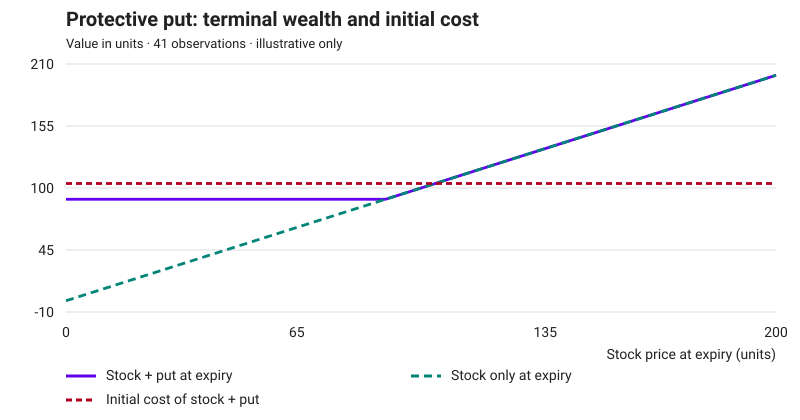

This is a payoff diagram across terminal prices, not a time-series path.


In [4]:
# Change these assumptions, then run this cell again.
spot, strike, premium, terminal = 100, 90, 4, 80
put_result = protective_put(spot=spot, strike=strike, premium=premium, terminal=terminal)
if premium < max(strike-spot, 0):
    print("This assumed premium violates the zero-interest no-arbitrage lower bound.")
    print("Read the result only as arithmetic for that hypothetical input, not a tradable price.")
for key, label in [("putPayoff", "Put payoff"), ("terminalWealth", "Terminal wealth"),
                   ("initialCost", "Initial cost"), ("profit", "Profit / loss"), ("returnPct", "Return (%)")]:
    print(f"{label:<20}: {put_result[key]:.6f}")
put_rows = []
for price in range(0, 201, 5):
    item = protective_put(spot=spot, strike=strike, premium=premium, terminal=price)
    put_rows.append(dict(price=price, wealth=item["terminalWealth"], cost=item["initialCost"], stock=price))
show_svg(chart_svg(put_rows, [("wealth", "Stock + put at expiry", "#6200EE", ""),
                            ("stock", "Stock only at expiry", "#008577", "8 5"),
                            ("cost", "Initial cost of stock + put", "#B00020", "6 4")],
                   x_key="price", title="Protective put: terminal wealth and initial cost",
                   x_label="Stock price at expiry (units)"))
print("This is a payoff diagram across terminal prices, not a time-series path.")

เครื่องมือถือสัญญาจนหมดอายุ ใช้ดอกเบี้ย 0% และไม่คิดเงินปันผล ค่าซื้อขาย ภาษี หรือการผิดนัด ค่า Premium เป็นค่าที่ผู้เรียนกำหนด **ไม่ได้คำนวณราคายุติธรรมของ Option** กราฟแกนนอนเป็นราคาที่อาจเกิด ณ วันหมดอายุ ไม่ใช่เส้นทางราคาตามเวลา

การถือสินทรัพย์กับ Put เป็นรูปแบบหนึ่งของ **[Option Based Portfolio Insurance หรือ OBPI](../glossary.html#obpi)** ซึ่งต้นฉบับอธิบายไว้ในบท 2 [พิมพ์ น. 10–13 / PDF 37–40](#references)

<a id="option-budget"></a>

## 3. ถ้ามีงบเพียง 100 ต้องลดอะไรลง

ตัวอย่างก่อนใช้เงิน 104 แต่คำถามต้นบทให้เรามีเพียง 100 การเปรียบเทียบกับพอร์ตที่ซื้อสินทรัพย์เสี่ยง 100 หน่วยจึงต้องจัดงบใหม่ ให้ค่าใช้จ่ายเพื่อป้องกันอยู่ภายในเงินตั้งต้นเดียวกัน

โครงสร้างอีกแบบของ OBPI คือ **สินทรัพย์ปลอดความเสี่ยงบวก Call** กันเงินส่วนแรกไว้ให้โตเป็น Floor ปลายทาง แล้วนำเงินส่วนที่เหลือซื้อ Call ซึ่งเปิดโอกาสรับการขึ้นของสินทรัพย์เหนือราคาใช้สิทธิ

ให้ $C_0$ เป็นราคา Call หนึ่งหน่วย และ $n$ เป็นจำนวนหน่วย Call ที่ซื้อได้ งบเริ่มต้นต้องสอดคล้องกับ

$$
V_0=F_Te^{-rT}+nC_0,
\qquad
n=\frac{V_0-F_Te^{-rT}}{C_0}.
$$

เมื่อ Call มีราคาใช้สิทธิ $K$ และครบกำหนดเดียวกับส่วนปลอดความเสี่ยง มูลค่าพอร์ตปลายทางคือ

$$
V_T=F_T+n\max(S_T-K,0).
$$

สูตรนี้ต้องมีงบเหลือไม่ติดลบและราคา Call มากกว่าศูนย์ หากต้องใช้เงินทั้งหมดกันไว้ให้ถึง Floor ก็จะไม่เหลืองบซื้อ Call การเพิ่มระดับป้องกันจึงลดเงินสำหรับรับโอกาสเติบโตเมื่อเงื่อนไขอื่นเท่าเดิม

### เชื่อมกับตัวอย่าง Put เดิม

ภายใต้สินทรัพย์ไม่มีเงินปันผล Option เป็น European ที่ราคาใช้สิทธิและวันหมดอายุเดียวกัน ดอกเบี้ย 0% และเงื่อนไขซื้อขายที่ไม่มีโอกาส Arbitrage ความสัมพันธ์ Put–call parity ให้

$$
C_0=S_0+P_0-K=100+4-90=14.
$$

นี่เป็นราคาที่สอดคล้องกับ **Premium สมมติ 4** ในตัวอย่าง ไม่ใช่ราคาตลาดที่สืบค้นมา ถ้ามีงบ 100 และต้องการ Floor 90 ให้กันเงิน 90 แล้วซื้อ Call ได้ $10/14=5/7$ หน่วย โดยสมมติว่าซื้อเศษหน่วยได้

$$
V_T=90+\frac{5}{7}\max(S_T-90,0).
$$

ถ้าสินทรัพย์จบที่ 80 พอร์ตนี้เหลือ 90 ถ้าจบที่ 120 พอร์ตมีประมาณ 111.43 หน่วย ได้กำไรประมาณ 11.43 หน่วยจากเงินเริ่มต้น 100 การคุ้มครองยังเปิดรับขาขึ้น แต่การเข้าร่วมขาขึ้นมีขนาดตามจำนวน Call ที่ซื้อได้

### ซื้อ Option จริงกับสร้าง Option สังเคราะห์

Option จริงเป็นสิทธิตามสัญญา อีกวิธีหนึ่งคือปรับจำนวนสินทรัพย์เสี่ยงกับเงินปลอดความเสี่ยงเพื่อเลียนแบบผลของ Option เรียกว่า **Synthetic option** ซึ่งต้องพึ่งความถูกต้องของแบบจำลองและการปรับพอร์ตตามเวลา

วิทยานิพนธ์ใช้ **Synthetic OBPI** ในการจำลองหลัก ผลของงานจึงไม่ควรถูกกล่าวรวมว่าเป็นผลจากการซื้อ Put จริงทุกแบบ การแยกวิธีดำเนินงานมีความหมายมากเมื่อซื้อขายได้เป็นรอบหรือราคาเคลื่อนที่รวดเร็ว [โครงสร้าง OBPI: พิมพ์ น. 10–13 / PDF 37–40; วิธีจำลอง: พิมพ์ น. 50–52 / PDF 77–79](#references)

In [5]:
# Same strike and expiry, zero interest and dividends: stock + put = bond + call.
spot, strike, assumed_put_premium = 100, 90, 4
implied_call_premium = spot + assumed_put_premium - strike
print(f"Parity-implied Call premium={implied_call_premium:.2f}; full stock+put cost=104.00")
budget, floor = 100, 90
call_units = (budget-floor)/implied_call_premium
print(f"With budget {budget}, reserve {floor} and buy {call_units:.6f} Call units, not one whole Call.")
for terminal_price in [80, 90, 120]:
    call_payoff = max(terminal_price-strike, 0)
    same_quantity = strike + call_payoff
    protected_budget = floor + call_units*call_payoff
    close(same_quantity, protective_put(terminal=terminal_price)["terminalWealth"])
    print(f"S_T={terminal_price}: full-parity wealth={same_quantity:.2f}; fixed-budget wealth={protected_budget:.2f}")

Parity-implied Call premium=14.00; full stock+put cost=104.00
With budget 100, reserve 90 and buy 0.714286 Call units, not one whole Call.
S_T=80: full-parity wealth=90.00; fixed-budget wealth=90.00
S_T=90: full-parity wealth=90.00; fixed-budget wealth=90.00
S_T=120: full-parity wealth=120.00; fixed-budget wealth=111.43


<a id="cppi-rule"></a>

## 4. CPPI ใช้ระยะห่างจาก Floor เป็นตัวกำหนดความเสี่ยง

อีกแนวทางหนึ่งไม่ต้องเริ่มจากราคา Option แต่เริ่มจากคำถามว่า **พอร์ตยังมีส่วนเผื่อเหนือ Floor เท่าไร** ส่วนเผื่อนี้เรียกว่า [Cushion](../glossary.html#cushion) และมีค่า

$$
C_t=V_t-F_t.
$$

ระวังว่าสัญลักษณ์ $C_t$ ในส่วนนี้หมายถึง Cushion ส่วน $C_0$ ในหัวข้อ OBPI ก่อนหน้าหมายถึงราคา Call ทั้งสองใช้คนละบริบท ตั้งแต่ส่วนนี้ไปเราจะใช้ $C_t$ สำหรับ Cushion เท่านั้น

กลยุทธ์ **[Constant Proportion Portfolio Insurance หรือ CPPI](../glossary.html#cppi)** กำหนดจำนวนเงินลงทุนในสินทรัพย์เสี่ยงจาก Cushion คูณด้วยค่าคงที่ $m$ ที่เรียกว่า [Multiplier](../glossary.html#multiplier)

$$
E_t=mC_t.
$$

$E_t$ คือจำนวนเงินเสี่ยง ไม่ใช่จำนวนหุ้นหรือสัดส่วนร้อยละ ส่วน $m$ ไม่มีหน่วย ตัวอย่างเช่น Cushion 10 และ $m=3$ ให้เงินลงทุนเสี่ยง 30 หน่วย ไม่ใช่ 300% ของพอร์ต

ในบทนี้ใช้รุ่น **ไม่กู้เงินและไม่ขายชอร์ต** จึงจำกัดเงินเสี่ยงไม่ให้ต่ำกว่าศูนย์หรือเกินมูลค่าพอร์ต

$$
E_t=\min\left(V_t,\max(0,mC_t)\right),
\qquad B_t=V_t-E_t.
$$

$B_t$ เป็นเงินในสินทรัพย์ปลอดความเสี่ยง เมื่อราคาหรือมูลค่าพอร์ตเปลี่ยน เราคำนวณ $C_t$ ใหม่ แล้วซื้อขายเพื่อให้ $E_t$ กลับมาตรงกฎ การทำเช่นนี้เรียกว่า [Rebalancing](../glossary.html#rebalancing) [กลไก CPPI: พิมพ์ น. 13–15 / PDF 40–42; กฎจำกัดเงินเสี่ยงในสมการ 4.27: พิมพ์ น. 52–53 / PDF 79–80](#references)

**Multiplier สูงไม่ได้สร้างการคุ้มครองมากขึ้น** แต่เปิดรับความเสี่ยงมากขึ้นจาก Cushion เท่ากัน ยิ่งลงทุนเสี่ยงมาก การเคลื่อนที่ของตลาดก็ยิ่งส่งผลต่อส่วนเผื่อได้มาก

<a id="cppi-example"></a>

## 5. คำนวณการปรับพอร์ตหนึ่งรอบด้วยตนเอง

กลับมาที่พอร์ตเริ่มต้น **100 หน่วย, Floor 90, $m=3$, ดอกเบี้ย 0%** สมมติไม่มีต้นทุนและถือสินทรัพย์เป็นเศษหน่วยได้ ที่จุดเริ่มต้นเรามี

$$
C_0=100-90=10,
\qquad E_0=3(10)=30,
\qquad B_0=100-30=70.
$$

ถ้าสินทรัพย์เสี่ยงลดลง 10% ก่อนรอบปรับพอร์ตครั้งถัดไป เงินเสี่ยง 30 จะเหลือ 27 ส่วนเงินปลอดความเสี่ยงยังอยู่ที่ 70 พอร์ตจึงมีมูลค่า

$$
V_1=30(1-0.10)+70=97.
$$

Cushion ใหม่เท่ากับ $97-90=7$ กฎต้องการเงินเสี่ยงเพียง $3(7)=21$ หน่วย แต่เรายังถืออยู่ 27 หน่วย จึงต้อง **ขายออก 6 หน่วย** แล้วไปเพิ่มเงินปลอดความเสี่ยง

| จุดคำนวณ | มูลค่าพอร์ต | Floor | Cushion | เงินเสี่ยง | เงินปลอดความเสี่ยง |
|---|---:|---:|---:|---:|---:|
| เริ่มต้น หลังจัดพอร์ต | 100 | 90 | 10 | 30 | 70 |
| หลังสินทรัพย์เสี่ยงลง 10% ก่อนปรับ | 97 | 90 | 7 | 27 | 70 |
| หลังปรับตามกฎ | 97 | 90 | 7 | 21 | 76 |

การซื้อขายครั้งนี้ไม่ได้สร้างเงินใหม่ มูลค่าพอร์ตยังเป็น 97 ต่างกันที่ว่ารอบต่อไปเราจะรับผลของสินทรัพย์เสี่ยงจากเงิน 21 หน่วย แทนที่จะเป็น 27 หน่วย

ถ้าสินทรัพย์ขึ้น 10% จากจุดเริ่มต้นแทน มูลค่าพอร์ตจะเป็น $30(1.10)+70=103$ Cushion เท่ากับ 13 และกฎต้องการเงินเสี่ยง 39 หน่วย เทียบกับเงินเสี่ยงที่โตมาเป็น 33 จึง **ซื้อเพิ่ม 6 หน่วย**

### ทดลองเปลี่ยนทีละค่า

เครื่องมือนี้แสดงการจัดสรร ณ จุดเริ่มต้นจากพอร์ต 100 หน่วยและดอกเบี้ย 0% ค่าเริ่มต้นคือ Floor 90% และ $m=3$ ลองคง Multiplier ไว้แล้วเพิ่ม Floor จากนั้นคืน Floor เดิมและเพิ่ม Multiplier สังเกตว่าจำนวนเงินเสี่ยงเปลี่ยนด้วยเหตุผลใด

In [6]:
# Worked allocation: initial 100, floor 90, multiplier 3, zero interest.
initial, floor_pct, multiplier = 100, 90, 3
first = calculate_allocation(initial, floor_pct, multiplier)
monthly_return = -0.10
held_risky_after_return = first["exposure"] * (1+monthly_return)
next_value = held_risky_after_return + first["safe"]
second = allocate(next_value, initial*floor_pct/100, multiplier)
print(f"Initial: cushion={first['cushion']:.2f}; risky={first['exposure']:.2f}; safe={first['safe']:.2f}")
print(f"After a 10% risky-asset fall: wealth={next_value:.2f}; risky before trade={held_risky_after_return:.2f}")
print(f"New risky target={second['exposure']:.2f}; sell={held_risky_after_return-second['exposure']:.2f}; safe={second['safe']:.2f}")
close(next_value, 97); close(second["exposure"], 21)
print("No future return was used to choose the preceding month's allocation.")

Initial: cushion=10.00; risky=30.00; safe=70.00
After a 10% risky-asset fall: wealth=97.00; risky before trade=27.00
New risky target=21.00; sell=6.00; safe=76.00
No future return was used to choose the preceding month's allocation.


เครื่องมือใช้กฎจำกัดเงินเสี่ยงที่ 0–100% ของพอร์ต จึงอาจเห็นเงินเสี่ยงหยุดเพิ่มเมื่อถึงเพดาน แม้เพิ่ม Multiplier ต่อ การคำนวณนี้ยังเป็นภาพ ณ เวลาเดียว ไม่ได้แสดงว่าพอร์ตจะรักษา Floor ได้ตลอดเส้นทาง

### กรณี $m=1$ ช่วยให้เห็นโครงสร้าง

ถ้า $m=1$ เงินเสี่ยงเท่ากับ Cushion และเงินปลอดความเสี่ยงเท่ากับ Floor เมื่อดอกเบี้ยและ Floor สอดคล้องกัน ไม่มีต้นทุน และราคาสินทรัพย์เสี่ยงไม่ติดลบ โครงสร้างนี้เสมือนกันส่วนปลอดความเสี่ยงไว้แล้วลงทุนส่วนที่เหลือในสินทรัพย์เสี่ยง ต้นฉบับจัดกรณีนี้เป็นกลยุทธ์ง่ายหรือ Naïve strategy [พิมพ์ น. 15 / PDF 42](#references)

<a id="gap-risk"></a>

## 6. เมื่อราคาลงเร็วกว่าที่จะปรับพอร์ต

กฎ CPPI ลดเงินเสี่ยงเมื่อ Cushion เล็กลง แต่การลดเกิดได้เฉพาะเมื่อเราซื้อขาย หากราคาลดแรงระหว่างสองรอบปรับพอร์ต เราอาจเห็น Floor หลังจากราคาผ่านมันไปแล้ว

ใช้จุดเริ่มต้นเดิม: เงินเสี่ยง 30, เงินปลอดความเสี่ยง 70, Floor 90 หากสินทรัพย์เสี่ยง **กระโดดลง 40% ในช่วงที่ยังปรับพอร์ตไม่ได้** มูลค่าพอร์ตจะเหลือ

$$
V_1=30(1-0.40)+70=88.
$$

พอร์ตต่ำกว่า Floor 90 ไปแล้ว เมื่อคำนวณ Cushion จะได้ $88-90=-2$ กฎที่จำกัดเงินเสี่ยงไม่ให้ติดลบจึงตั้งเป้าเงินเสี่ยงเป็นศูนย์ การขายหลังจากนั้นไม่สามารถทำให้มูลค่า 88 ย้อนกลับเป็น 90 ได้

นี่คือ **[Gap risk](../glossary.html#gap-risk)** ความเสี่ยงที่การเคลื่อนที่ของราคาทำให้พอร์ตผ่านระดับป้องกันก่อนปรับได้ทัน ประเด็นนี้อภิปรายในวิทยานิพนธ์ รวมถึงความยากเมื่อความสัมพันธ์ของสินทรัพย์เปลี่ยนในช่วงตลาดตึงตัว [พิมพ์ น. 32–33 / PDF 59–60](#references)

### Multiplier เชื่อมกับความไวต่อการร่วงอย่างไร

สมมติยังไม่ติดเพดานเงินเสี่ยง $E_t=mC_t$, Cushion เป็นบวก, ดอกเบี้ย 0% และไม่มีต้นทุน ถ้าสินทรัพย์เสี่ยงลดลงเป็นสัดส่วน $d$ ในหนึ่งช่วง มูลค่าที่หายไปคือ $mC_td$ ดังนั้น Cushion ที่เหลือคือ

$$
C_{t+1}=C_t-mC_td=C_t(1-md).
$$

เมื่อ $d>1/m$ Cushion จะติดลบ สำหรับ $m=3$ จุดนี้อยู่ที่การลดลงมากกว่าประมาณ 33.33% ในช่วงเดียว สูตรนี้เป็นข้อสังเกตภายใต้เงื่อนไขที่เพิ่งระบุ ไม่ใช่เกณฑ์สากลของทุกผลิตภัณฑ์ เมื่อเงินเสี่ยงติดเพดานหรือ Floor เปลี่ยน ต้องกลับไปคำนวณจากเงินจริงอีกครั้ง

### Cash lock: ตลาดฟื้น แต่พอร์ตไม่ตาม

หาก Cushion หมดก่อนครบกำหนดจนกฎให้เงินเสี่ยงเป็นศูนย์ พอร์ตอาจอยู่ในสินทรัพย์ปลอดความเสี่ยงต่อไปโดยไม่มีส่วนร่วมกับการฟื้นตัว เรียกว่า **[Cash lock](../glossary.html#cash-lock)** ในตัวอย่างดอกเบี้ย 0% หลังพอร์ตลดเหลือ 88 แล้วขายสินทรัพย์เสี่ยงทั้งหมด แม้สินทรัพย์อ้างอิงขึ้นภายหลัง พอร์ตก็ยังอยู่ที่ 88 [แนวคิด Cash lock: พิมพ์ น. 14 / PDF 41](#references)

ไม่ใช่ทุกการลดความเสี่ยงจะกลายเป็น Cash lock หากยังมี Cushion บวกและยังถือสินทรัพย์เสี่ยง พอร์ตอาจกลับมาเพิ่มเงินเสี่ยงได้ การที่ Multiplier เป็นศูนย์ตั้งแต่ต้นก็เป็นการเลือกไม่รับความเสี่ยง ไม่ใช่ Cushion ถูกใช้จนหมด

### ทดลองทั้งเส้นทาง ไม่ดูเพียงราคาเริ่มกับราคาจบ

เครื่องมือต่อไปใช้เส้นทางผลตอบแทนสมมติ 12 เดือน เริ่มด้วยพอร์ต 100, Floor 90%, $m=3$ และดอกเบี้ย 0% ลองดู “ร่วงฉับพลัน” เพื่อสังเกตการหลุด Floor แล้วเปลี่ยนเป็น “ลงก่อนแล้วฟื้น” เพื่อดูผลของการลดเงินเสี่ยงก่อนตลาดกลับขึ้น

Scenario=crash; terminal floor=90%; m=3; annual continuous rate=0.00%
CPPI final=87.411904; return=-12.588096%; max monthly drawdown=15.085004%
Floor breached=True; cash locked=True; rebalance turnover=29.173824 units


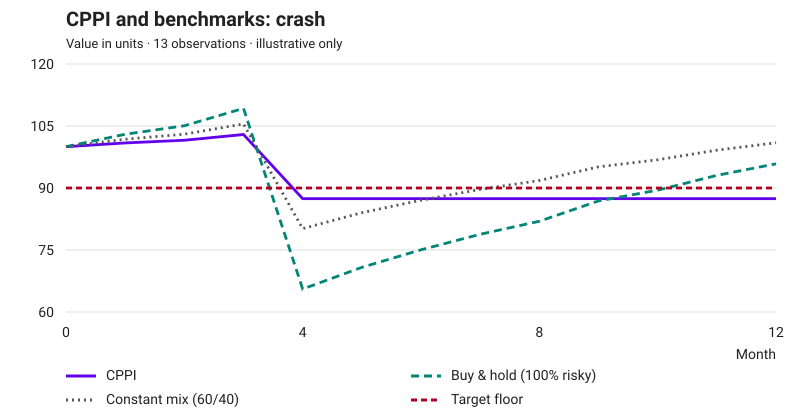

Month   CPPI      Buy/hold  Mix60/40  Floor     Risky target  Cushion
    0  100.0000  100.0000  100.0000   90.0000      30.0000   10.0000
    1  100.9000  103.0000  101.8000   90.0000      32.7000   10.9000
    2  101.5540  105.0600  103.0216   90.0000      34.6620   11.5540
    3  102.9405  109.2624  105.4941   90.0000      38.8214   12.9405
    4   87.4119   65.5574   80.1755   90.0000       0.0000   -2.5881
    5   87.4119   70.8020   84.0240   90.0000       0.0000   -2.5881
    6   87.4119   75.0502   87.0488   90.0000       0.0000   -2.5881
    7   87.4119   78.8027   89.6603   90.0000       0.0000   -2.5881
    8   87.4119   81.9548   91.8121   90.0000       0.0000   -2.5881
    9   87.4119   86.8721   95.1174   90.0000       0.0000   -2.5881
   10   87.4119   89.4782   96.8295   90.0000       0.0000   -2.5881
   11   87.4119   93.0573   99.1534   90.0000       0.0000   -2.5881
   12   87.4119   95.8491  100.9381   90.0000       0.0000   -2.5881
Month 12 exposure is a formula ta

In [7]:
# Editable controls: rally, crash, whipsaw, or recovery; initial wealth 100.
scenario, floor_pct, multiplier, rate = "crash", 90, 3, 0
result = simulate(scenario=scenario, floor_pct=floor_pct, multiplier=multiplier, rate=rate)
metrics = result["metrics"]
print(f"Scenario={scenario}; terminal floor={floor_pct}%; m={multiplier}; annual continuous rate={rate:.2%}")
print(f"CPPI final={metrics['final']:.6f}; return={metrics['returnPct']:.6f}%; max monthly drawdown={metrics['maxDrawdownPct']:.6f}%")
print(f"Floor breached={metrics['floorBreached']}; cash locked={metrics['locked']}; rebalance turnover={metrics['totalTurnover']:.6f} units")
show_svg(chart_svg(result["rows"], CPPI_SERIES, title=f"CPPI and benchmarks: {scenario}"))
print("Month   CPPI      Buy/hold  Mix60/40  Floor     Risky target  Cushion")
for row in result["rows"]:
    print(f"{row['month']:>5} {row['cppi']:>9.4f} {row['buyHold']:>9.4f} {row['constantMix']:>9.4f} {row['floor']:>9.4f} {row['exposure']:>12.4f} {row['cushion']:>9.4f}")
print("Month 12 exposure is a formula target only; no final trade enters turnover.")
csv_text = cppi_csv(result)  # Optionally save this string to a file of your choice.
print("\nSame parameters, four illustrative paths:")
for path in SCENARIOS:
    comparison = simulate(scenario=path, floor_pct=floor_pct, multiplier=multiplier, rate=rate)
    stats = comparison["metrics"]
    print(f"{path:<10} final={stats['final']:.5f}, breach={stats['floorBreached']}, cash lock={stats['locked']}")

**สมมติฐานของการทดลอง:** ปรับพอร์ตตอนเริ่มและหลังสิ้นเดือนที่ 1–11 โดยใช้เฉพาะข้อมูลที่เกิดขึ้นแล้ว ถือหน่วยลงทุนเป็นเศษส่วนได้ ไม่กู้และไม่ขายชอร์ต ไม่มีค่าธรรมเนียม ภาษี ส่วนต่างราคาซื้อขาย หรือความคลาดเคลื่อนจากราคาส่งคำสั่ง เงินปลอดความเสี่ยงให้ดอกเบี้ย 0% จึงทำให้ Floor ระหว่างทางคงที่ ผลที่แสดงเป็นจุดรายเดือน มูลค่าระหว่างเดือนอาจต่างออกไป

ตัวเปรียบเทียบหนึ่งคือถือสินทรัพย์เสี่ยง 100% ตลอดช่วง อีกตัวคือ **Constant Mix 60/40** ที่ปรับกลับเป็นสินทรัพย์เสี่ยง 60% กับปลอดความเสี่ยง 40% ทุกเดือน ทั้งคู่ใช้เงินตั้งต้น 100 เช่นกัน พอร์ต 60/40 นี้เป็นตัวเปรียบเทียบที่เพิ่มเพื่อการสอน **ต่างจากพอร์ต 50:50 แบบ Passive ในวิทยานิพนธ์** และเส้นทางทั้งสี่ไม่ใช่ผล Monte Carlo จากต้นฉบับ

ค่าซื้อขายสะสมหรือ Turnover นับจำนวนเงินที่ซื้อหรือขายฝั่งสินทรัพย์เสี่ยงในเดือนที่ 1–11 ไม่นับจัดพอร์ตครั้งแรก เป็นหน่วยเงิน ไม่ใช่ค่าธรรมเนียมหรืออัตราร้อยละ ส่วนการหลุด Floor และ Drawdown วัดที่จุดรายเดือน ผลว่าไม่หลุดในเส้นทางหนึ่งจึงยังไม่บอกว่าจะไม่หลุดในเส้นทางอื่น

<a id="tipp"></a>

## 7. TIPP เพิ่มคำถามว่า กำไรที่เกิดขึ้นควรปกป้องด้วยหรือไม่

CPPI แบบ Floor คงที่ตั้งเป้าจากเงินเริ่มต้น หากพอร์ตโตจาก 100 เป็น 120 แล้วลดกลับลงมา จุดป้องกันเดิมอาจยังอยู่ที่ 90 ผู้ลงทุนจึงอาจรู้สึกว่า “เคยมี 120 แล้ว” และต้องการรักษาการเติบโตบางส่วนไว้ด้วย

**[Time Invariant Portfolio Protection หรือ TIPP](../glossary.html#tipp)** ต่อยอดจาก CPPI โดยยก Floor ตามเงื่อนไขเมื่อพอร์ตเติบโต การยก Floor แบบไม่ลดกลับเรียกว่า Ratchet หลักการคือให้กำไรบางส่วนเข้ามาอยู่ในเป้าหมายป้องกัน [พิมพ์ น. 15–16 / PDF 42–43](#references)

เพื่อเห็นกลไก ลองกำหนด **ตัวอย่างใหม่ที่ดอกเบี้ย 0%**: ยก Floor ให้เท่ากับ 90% ของจุดสูงสุดมูลค่าพอร์ตที่สังเกตได้ และไม่ลด Floor กลับ หาก $H_t$ เป็นมูลค่าสูงสุดของพอร์ตจนถึงเวลา $t$ จะได้ $F_t=0.90H_t$ ตัวอย่างนี้เป็นกฎที่บทเรียนกำหนดเพื่ออธิบาย ไม่ใช่การทำซ้ำผล TIPP ในวิทยานิพนธ์

เมื่อพอร์ตมีมูลค่า 120 และเป็นจุดสูงสุดใหม่ Floor จะเพิ่มจาก 90 เป็น 108 Cushion จึงเป็น $120-108=12$ หากใช้ $m=3$ จะได้เงินเสี่ยงเป้าหมาย 36 หน่วย เทียบกับ CPPI Floor เดิม 90 ซึ่งมี Cushion 30 และเงินเสี่ยงเป้าหมาย 90 หน่วย

เราเห็นสิ่งที่แลกกันได้ทันที: **การปกป้องกำไรทำให้เหลือพื้นที่รับความเสี่ยงน้อยลง** พอร์ตอาจรับการขึ้นรอบถัดไปได้น้อยกว่า แต่รักษาระดับป้องกันสูงขึ้น การยก Floor ไม่ได้ลบ Gap risk หากยังปรับสินทรัพย์เป็นรอบ จึงต้องระบุทั้งกฎยก Floor และความถี่ปรับพอร์ตก่อนเปรียบเทียบ TIPP แต่ละแบบ

In [8]:
# The chapter's illustrative ratchet rule, not a replication of the thesis.
current_value, high_water_mark, protection_fraction, multiplier = 120, 120, 0.90, 3
fixed_floor = 90
ratchet_floor = protection_fraction*high_water_mark
tipp_allocation = allocate(current_value, ratchet_floor, multiplier)
cppi_allocation = allocate(current_value, fixed_floor, multiplier)
close(ratchet_floor, 108); close(tipp_allocation["exposure"], 36)
close(cppi_allocation["exposure"], 90)
print(f"At wealth 120: TIPP floor={ratchet_floor:.2f}, cushion={tipp_allocation['cushion']:.2f}, risky target={tipp_allocation['exposure']:.2f}")
print(f"Fixed-floor CPPI: floor={fixed_floor:.2f}, cushion={cppi_allocation['cushion']:.2f}, risky target={cppi_allocation['exposure']:.2f}")
print("A higher floor leaves less risky exposure; monthly rebalancing still leaves gap risk.")

At wealth 120: TIPP floor=108.00, cushion=12.00, risky target=36.00
Fixed-floor CPPI: floor=90.00, cushion=30.00, risky target=90.00
A higher floor leaves less risky exposure; monthly rebalancing still leaves gap risk.


<a id="strategies"></a>

## 8. วางสี่กลยุทธ์ข้างกัน แล้วดูว่าต่างกันตรงไหน

ยังมีวิธีง่ายอีกแบบคือ **Stop Loss Portfolio Insurance หรือ SLPI** เริ่มจากถือสินทรัพย์เสี่ยง แล้วขายไปถือสินทรัพย์ปลอดความเสี่ยงเมื่อมูลค่าลดถึงเกณฑ์ ในรุ่นที่วิทยานิพนธ์จำลอง เมื่อขายแล้วจะถือส่วนปลอดความเสี่ยงจนจบช่วงลงทุน จึงอาจพลาดการฟื้นตัว การขายที่เกณฑ์ก็อาจทำไม่ได้หากราคากระโดดผ่าน [พิมพ์ น. 9, 50 / PDF 36, 77](#references)

เราจึงมีวิธีป้องกันสี่แบบที่ไม่ได้ใช้กลไกเดียวกัน

| กลยุทธ์ | กฎหรือสิทธิที่ใช้ | โอกาสเติบโตมาจาก | จุดที่ต้องระวัง |
|---|---|---|---|
| **SLPI** | ขายสินทรัพย์เสี่ยงเมื่อแตะเกณฑ์ | การถือสินทรัพย์เสี่ยงก่อนขาย | อาจขายต่ำกว่าเกณฑ์ และรุ่นไม่กลับเข้าตลาดอาจพลาดการฟื้นตัว |
| **OBPI** | ซื้อ Option หรือปรับพอร์ตเพื่อเลียนแบบ Option | สินทรัพย์เสี่ยงหรือจำนวน Call ที่งบซื้อได้ | ต้องรวมค่า Option ในงบ แยกสิทธิตามสัญญาจากความเสี่ยงการเลียนแบบ |
| **CPPI** | กำหนดเงินเสี่ยงจาก Multiplier × Cushion | เงินเสี่ยงที่เพิ่มเมื่อ Cushion โต | Gap risk, Cash lock และต้นทุนการปรับพอร์ต |
| **TIPP** | กฎแบบ CPPI พร้อมยก Floor | ส่วนเผื่อเหนือ Floor ที่ยกขึ้นแล้ว | ปกป้องกำไรเพิ่ม แต่พื้นที่รับขาขึ้นอาจลดลง และยังเสี่ยงจากการปรับไม่ทัน |

ตารางสรุปกลไกจากบท 2 ไม่ใช่อันดับผลตอบแทน [พิมพ์ น. 9–16 / PDF 36–43](#references) ก่อนบอกว่าแบบใดดีกว่า ต้องทำให้เงินเริ่มต้น ระยะเวลา เป้าหมายป้องกัน และต้นทุนที่รวมอยู่สอดคล้องกัน

### จากพอร์ตหนึ่งใบสู่ตลาดที่หลายคนใช้กฎคล้ายกัน

CPPI ในตัวอย่างขายหลังราคาลงและซื้อเพิ่มหลังราคาขึ้น หากผู้ใช้จำนวนมากต้องทำธุรกรรมทิศเดียวกันในตลาดที่สภาพคล่องต่ำ คำสั่งซื้อขายอาจทำได้ยากกว่าที่สูตรสมมติไว้ และผลกระทบต่อราคาอาจย้อนกลับมากระทบกฎป้องกันเอง

บท 3 ของวิทยานิพนธ์ทบทวนประเด็นการซื้อขายตามกฎกับเสถียรภาพตลาด ทั้งสภาพคล่อง ข้อมูลที่ไม่สมบูรณ์ และข้อจำกัดในการป้องกัน Gap risk ประเด็นนี้เตือนว่า “กฎเหมาะกับพอร์ตหนึ่งใบ” ยังไม่ครบสำหรับการประเมินผลเมื่อหลายพอร์ตทำพร้อมกัน งานส่วนนี้เป็นการทบทวนและอภิปราย ไม่ใช่ผลจากเครื่องมือ 12 เดือนในหน้านี้ [พิมพ์ น. 23–36 โดยเฉพาะ น. 32–33 / PDF 50–63, 59–60](#references)

<a id="study-design"></a>

## 9. วิทยานิพนธ์ทดสอบกลยุทธ์เหล่านี้อย่างไร

ถึงตรงนี้เราอธิบายกลไกจากตัวเลขไม่กี่ช่วงได้แล้ว แต่ยังไม่รู้ว่ากลยุทธ์มีแนวโน้มให้ผลแบบใดเมื่อเจอสถานการณ์หลายรูปแบบ งานในบท 4–5 จึงใช้ **Monte Carlo simulation** สร้างเส้นทางจำนวนมาก แล้วนำกลยุทธ์ไปทำงานบนเส้นทางจำลอง

ราคาสินทรัพย์เสี่ยงในงานใช้ **[Geometric Brownian Motion หรือ GBM](../glossary.html#gbm)** ภายใต้พารามิเตอร์คงที่ Log return ของช่วงเวลาที่กำหนดเป็น Normal และระดับราคาปลายช่วงเป็น Lognormal ราคาจึงเป็นบวก แต่กระบวนการต่อเนื่องพื้นฐานนี้ไม่ได้ใส่การกระโดดของราคาแบบฉับพลันไว้

| องค์ประกอบการทดลอง | ที่ระบุในวิทยานิพนธ์ |
|---|---|
| ระยะเวลา | 1 ปี, 252 วันซื้อขาย |
| จำนวนเส้นทาง | 100,000 เส้นทางต่อสถานการณ์ |
| สถานการณ์ | 9 คู่ของผลตอบแทนที่ตั้งไว้ 5%, 10%, 15% และความผันผวน 10%, 20%, 30% ต่อปี |
| อัตราปลอดความเสี่ยงฐาน | 5% ต่อปี |
| กลยุทธ์ป้องกัน | SLPI, Synthetic OBPI, CPPI $m=1$ และ $m=3$, TIPP |
| ตัวเปรียบเทียบ | ถือสินทรัพย์เสี่ยง, จัดเงินเริ่มต้นเสี่ยง/ปลอดความเสี่ยง 50:50 แบบ Passive, สินทรัพย์ปลอดความเสี่ยง |
| ข้อจำกัด CPPI | เงินลงทุนเสี่ยงอยู่ระหว่างศูนย์กับมูลค่าพอร์ต |
| ต้นทุนที่ไม่รวม | ภาษี ส่วนต่างราคาซื้อขาย และค่าธรรมเนียมซื้อขาย |

ข้อมูลนี้มาจากวิธีวิจัยในพิมพ์ น. 48–53 และ 85–86 / PDF 75–80 และ 112–113 [ดูต้นฉบับ](#references) อัตราเหล่านี้เป็นค่าตั้งต้นของการทดลอง ไม่ใช่ประมาณการตลาดปัจจุบัน และพอร์ต 50:50 ในงานไม่ได้ปรับกลับเป็น 50:50 ทุกวัน

Floor หลักคือ 100% ของเงินเริ่มต้น จากนั้นงานทดสอบความไวโดยเปลี่ยน Floor เป็น 80% เปลี่ยนพารามิเตอร์ CPT และเปลี่ยนอัตราปลอดความเสี่ยงเป็น 3.5% กับ 6.5% [พิมพ์ น. 91–98 / PDF 118–125](#references)

<a id="limitations"></a>

### อ่านผลพร้อมขอบเขตของการทดลอง

หนึ่งปีอาจเหมาะกับคำถามเปรียบเทียบช่วงสั้น แต่ยังไม่ครอบคลุมเป้าหมายหลายสิบปี ผู้เขียนระบุว่าควรศึกษาระยะยาวเพิ่ม โดยเฉพาะ CPPI/TIPP และเป้าหมายเกษียณ อีกทั้งต้นทุนที่ไม่รวมอาจสำคัญกับกลยุทธ์ที่ซื้อขายบ่อย [พิมพ์ น. 49 และเชิงอรรถ 7 / PDF 76](#references)

ค่าความชอบที่ใช้ในแบบจำลองก็ไม่ได้ประมาณจากเจ้าของพอร์ตแต่ละคน เราจึงไม่ควรอ่านผลว่าเป็นการระบุตัวเลือกที่เหมาะสมสำหรับผู้อ่านรายใดโดยตรง กฎ Floor, Multiplier และวิธีใช้ Option ล้วนมีผลต่อสิ่งที่กำลังเปรียบเทียบ

ควรแยก **[Sampling error](../glossary.html#sampling-error)** หรือความคลาดเคลื่อนจากใช้ตัวอย่างสุ่มจำกัด ออกจาก **[Model risk](../glossary.html#model-risk)** หรือความเสี่ยงจากสมมติฐานและแบบจำลอง การเพิ่มจำนวนเส้นทางช่วยลดส่วนแรก แต่ไม่ทำให้สมมติฐานตลาดสมจริงขึ้นโดยอัตโนมัติ

<a id="eut-cpt"></a>

## 10. เหตุใดกลยุทธ์ที่ไม่ได้ผลตอบแทนสูงสุดจึงยังน่าดึงดูด

การจัดอันดับต้องเริ่มจากสิ่งที่เราต้องการวัด ผู้ลงทุนอาจไม่ได้ให้คุณค่ากับกำไรเพิ่มหนึ่งหน่วยเท่ากันทุกระดับความมั่งคั่ง และอาจรู้สึกต่อการขาดทุนต่างจากกำไรขนาดเท่ากัน งานจึงเปรียบเทียบกรอบการประเมินสองแนวทาง

### EUT ประเมินความมั่งคั่งผ่าน Utility

**Expected Utility Theory หรือ EUT** ใช้เกณฑ์ค่าสูงสุดของ [อรรถประโยชน์คาดหมาย](../glossary.html#expected-utility)

$$
\mathbb{E}[U(W_T)].
$$

$W_T$ คือความมั่งคั่งเมื่อจบช่วงลงทุน และ $U$ เป็นฟังก์ชันบอกคุณค่าของความมั่งคั่ง การเพิ่ม $\mathbb{E}[U(W_T)]$ ไม่ได้เท่ากับเพิ่ม $\mathbb{E}[W_T]$ เสมอ ทั้งสองให้เกณฑ์เดียวกันเมื่อ Utility เป็นเส้นตรง

บท 5 ใช้ $U(W)=\ln W$ แทนผู้หลีกเลี่ยงความเสี่ยง, $U(W)=W$ แทนผู้เป็นกลางต่อความเสี่ยง และ $U(W)=W^2$ แทนผู้ชอบความเสี่ยงบนช่วงความมั่งคั่งบวก ผลภายใต้กรณีที่เลือกไม่ได้สนับสนุนอย่างชัดเจนว่า Portfolio Insurance เป็นตัวเลือกอันดับแรกโดยทั่วไป จึงยังอธิบายความนิยมของผลิตภัณฑ์ได้ไม่ดี [พิมพ์ น. 86–89, ตาราง 5.1 / PDF 113–116](#references)

ผลนี้ไม่ใช่บทพิสูจน์ว่า Portfolio Insurance ไม่มีคุณค่าสำหรับผู้ใช้ EUT ทุกคน บท 4 เองแสดงว่าความผันผวน ผลตอบแทนที่ตั้งไว้ และระดับ Risk aversion สามารถเปลี่ยนการเลือกกลยุทธ์ได้ [พิมพ์ น. 76–78 / PDF 103–105](#references)

### CPT ประเมินกำไรและขาดทุนเทียบจุดอ้างอิง

**[Cumulative Prospect Theory หรือ CPT](../glossary.html#cpt)** มองผลลัพธ์เทียบ [Reference point](../glossary.html#reference-point) แล้วให้คุณค่าแก่กำไรและขาดทุนต่างกัน พร้อมใช้น้ำหนักการตัดสินใจที่คำนวณจากความน่าจะเป็นสะสม

งานใช้เงินเริ่มต้น 100 เป็นจุดอ้างอิงในตารางผล เมื่อเปลี่ยน Floor เป็น 80 จุดอ้างอิงก็ยังเป็นเงินเริ่มต้น 100 การทำพอร์ตได้ 90 จึงอาจสูงกว่า Floor แต่ยังเป็นผลขาดทุนเมื่อเทียบจุดอ้างอิง [พิมพ์ น. 84–85, 90, 95 / PDF 111–112, 117, 122](#references)

ให้ $x$ เป็นความมั่งคั่งปลายทางลบจุดอ้างอิง รูปแบบ Value function ที่ใช้คือ

$$
v(x)=\begin{cases}
x^\alpha & x\geq0,\\
-\lambda(-x)^\beta & x<0.
\end{cases}
$$

$\alpha$ และ $\beta$ กำกับความไวต่อขนาดกำไรและขาดทุน ส่วน $\lambda$ กำกับ [Loss aversion](../glossary.html#loss-aversion) หรือความไวต่อการสูญเสียเทียบกับกำไร งานใช้ค่าฐาน $\alpha=\beta=0.88$, $\lambda=2.25$ พร้อมพารามิเตอร์ถ่วงน้ำหนักความน่าจะเป็นของกำไร 0.61 และขาดทุน 0.69 จากวรรณกรรมที่อ้างไว้ [พิมพ์ น. 84 / PDF 111](#references)

การใช้ Value function นี้แล้วหาเฉลี่ยธรรมดายังไม่ใช่ CPT ครบรูปแบบ ต้องเรียงผลลัพธ์และคำนวณน้ำหนักจากความน่าจะเป็นสะสมด้วย น้ำหนักการตัดสินใจไม่ใช่โอกาสเกิดจริงที่แก้ใหม่ [พิมพ์ น. 83–84 / PDF 110–111](#references)

<a id="findings"></a>

### เปลี่ยนเกณฑ์มองแล้ว ผลจัดอันดับเปลี่ยนอย่างไร

ตัวอย่างต่อไปอ่านจาก **ตาราง 5.2 Panel C** ซึ่งใช้ CPT และ Floor 100% ในการทดลองฐาน

| สถานการณ์จำลอง | SLPI | CPPI $m=3$ | ถือสินทรัพย์เสี่ยง |
|---|---:|---:|---:|
| ผลตอบแทนที่ตั้งไว้ 15%, ความผันผวน 30% | 17.04 | 11.61 | 6.96 |
| ผลตอบแทนที่ตั้งไว้ 15%, ความผันผวน 10% | 15.50 | 6.58 | 15.83 |

**ตัวเลขเป็นคะแนน Cumulative prospect value ตามสเกลของงาน ไม่ใช่ผลตอบแทนร้อยละหรือจำนวนเงิน** ในตารางฐานนี้ SLPI ได้คะแนนสูงสุดใน 8 จาก 9 สถานการณ์ ข้อยกเว้นคือผลตอบแทนที่ตั้งไว้สูงกับความผันผวนต่ำ ซึ่งการถือสินทรัพย์เสี่ยงได้คะแนนสูงกว่า [พิมพ์ น. 90–91 / PDF 117–118](#references)

เมื่อลด Floor เป็น 80% การจัดอันดับเปลี่ยนและ CPPI มีบทบาทมากขึ้นในหลายสถานการณ์ ผู้เขียนจึงสรุปว่า CPT **อาจช่วยอธิบายความนิยม** ของ Portfolio Insurance ได้ แต่การเลือกแบบใดยังขึ้นกับเงื่อนไขตลาดและการออกแบบกลยุทธ์ [พิมพ์ น. 95, 97–98 / PDF 122, 124–125](#references)

ข้อสรุปนี้เกี่ยวกับคุณค่าที่ผู้ลงทุนตามแบบจำลองรับรู้ ไม่ได้ยืนยันว่ากลยุทธ์ที่นิยมจะให้ผลตอบแทนสูงที่สุด หรือรักษา Floor ได้จริงในทุกเงื่อนไข ความน่าดึงดูดใจ ประสิทธิภาพการลงทุน และความสามารถดำเนินการจึงเป็นสามคำถามที่ต้องอ่านคู่กัน

<a id="robo-advisors"></a>

## 11. ถ้าให้แบบสอบถามเลือกพอร์ตแทนเรา จะวัดความเสี่ยงได้ครบหรือไม่

เมื่อความชอบต่อการขาดทุนและความคุ้มครองมีผลต่อการเลือกกลยุทธ์ คำถามต่อมาคือเราจะรู้ความชอบเหล่านั้นได้อย่างไร บท 6 ของวิทยานิพนธ์จึงศึกษาการแปลงแบบสอบถามเป็นพอร์ตผ่านแพลตฟอร์ม Robo-advisors

งานศึกษาตัวอย่าง **5 แพลตฟอร์ม** ตามการเข้าถึงและข้อมูลที่มีในช่วงจัดทำวิทยานิพนธ์ แล้วสร้างผู้ลงทุนแบบ Conservative, Moderate และ Aggressive เพื่อเปรียบเทียบสิ่งที่แต่ละแพลตฟอร์มให้ งานจัดองค์ประกอบคำถามเป็นสี่ด้าน: ความคาดหวัง ความสามารถรับความเสี่ยง ความชอบความเสี่ยง และความตระหนักถึงความเสี่ยง [พิมพ์ น. 108–110 / PDF 135–137](#references)

ผู้วิจัยพบว่าพอร์ตจากโปรไฟล์ลักษณะเดียวกันมีการจัดสรรและรูปแบบ Risk–return ต่างกัน จึงตั้งข้อกังวลว่าความเข้าใจของผู้ลงทุนกับสิ่งที่พอร์ตส่งมอบอาจไม่ตรงกัน [พิมพ์ น. 114–117, 120–121 / PDF 141–144, 147–148](#references)

การอ่านผลต้องคำนึงถึงวิธีประเมินด้วย

- **ตัวอย่างมีขนาดเล็กและขึ้นกับการเข้าถึง** จึงไม่ได้แทนทุกแพลตฟอร์ม [พิมพ์ น. 108 / PDF 135](#references)
- **บางสินทรัพย์ใช้ตัวแทนในการทดสอบย้อนหลัง** เมื่อไม่มีสินทรัพย์หรือข้อมูลราคาตรงตัว งานใช้ ETF หรือดัชนีใกล้เคียง และนำข้อมูลย้อนหลังมาวิเคราะห์ ไม่ใช่ผลดำเนินการจริงของบัญชีลูกค้าทุกราย [พิมพ์ น. 111–112 / PDF 138–139](#references)
- **การแยกความเสี่ยงใช้สมมติฐานที่ทำให้ง่ายขึ้น** แต่ละดัชนีมีตัวขับเคลื่อนความเสี่ยงหลักหนึ่งประเภท และสมมติความสัมพันธ์ระหว่างประเภทความเสี่ยงเป็นศูนย์ [พิมพ์ น. 113 / PDF 140](#references)

เนื้อหาส่วนนี้จึงเป็นกรณีศึกษาจากงานปี 2018 ไม่ใช่การจัดอันดับบริการในปัจจุบัน และความแตกต่างระหว่างพอร์ตเพียงอย่างเดียวยังไม่พิสูจน์ว่าทุกพอร์ตไม่เหมาะสม

สิ่งที่เชื่อมกลับมายังบทเรียนคือคำว่า “รับความเสี่ยงได้ปานกลาง” ยังอาจไม่บอก Floor ที่ต้องการ เวลาที่จะใช้เงิน หรือความพร้อมยอมพลาดการฟื้นตัวหลังขายลดความเสี่ยง การประเมินพอร์ตจึงต้องกลับมาที่เงื่อนไขของผู้ลงทุนและกลไกที่ใช้ ไม่จบที่ชื่อกลุ่มความเสี่ยงเพียงคำเดียว

<a id="how-to-compare"></a>

## 12. ทบทวนสิ่งที่ต้องรู้ก่อนบอกว่าการป้องกันคุ้มค่า

เราเริ่มจากงบ 100 และความต้องการรักษาเงิน 90 แต่คำตอบเปลี่ยนไปตามวิธีดำเนินงาน การซื้อ Option มีต้นทุนชัดเจน ส่วนการปรับพอร์ตตามกฎมีความเสี่ยงที่ราคาเคลื่อนที่เร็วกว่ารอบซื้อขาย TIPP เพิ่มความคุ้มครองกำไรระหว่างทาง แต่ก็ลดส่วนเผื่อที่ใช้รับการเติบโตได้

เวลาประเมินผล ควรวางอย่างน้อยสี่ด้านไว้ข้างกัน

| สิ่งที่กำลังวัด | ช่วยตอบคำถามใด |
|---|---|
| ผลตอบแทนปลายทาง | เงินตั้งต้นเติบโตหรือลดลงเท่าไร |
| การหลุด Floor | ต่ำกว่าเป้าหมายหรือไม่ ต่ำกว่าเท่าไร และเกิดเมื่อใด |
| Maximum drawdown | ลดลงจากจุดสูงสุดก่อนหน้ามากเท่าไร |
| ต้นทุนและการซื้อขาย | ต้องแลกด้วยค่า Option ค่าซื้อขาย และการปรับพอร์ตมากเพียงใด |

[Drawdown](../glossary.html#drawdown) ต่างจากการขาดทุนเทียบเงินต้น ตัวอย่างเช่นพอร์ตเริ่ม 100 โตไป 120 แล้วลดเหลือ 108 ยังมีกำไร 8% เทียบเงินต้น แต่มี Drawdown 10% จากจุดสูงสุด ถ้า Floor อยู่ที่ 90 ก็ยังไม่หลุด Floor ทั้งสามค่าบอกคนละด้านของเส้นทางเดียวกัน

### ลองอธิบายด้วยคำของตนเอง

ลองตอบก่อนเปิดแนวคำตอบ หากยังอธิบายข้อใดไม่ได้ ให้กลับไปดูตัวอย่างหรือเปลี่ยนค่าทีละตัวในเครื่องมือ เพื่อเชื่อมผลที่เห็นกับเงินที่ถืออยู่จริง

**1. หุ้นราคา 100 บวก Put ราคา 4 ที่ K = 90 มีมูลค่าปลายทางอย่างน้อย 90 แล้วเหตุใดจึงยังขาดทุน 14 ได้**

เพราะมูลค่าปลายทางกับเงินลงทุนตั้งต้นเป็นคนละจำนวน ผู้ซื้อจ่าย 104 หน่วย หากมูลค่ารวมปลายทางเป็น 90 ผลขาดทุนคือ 90 − 104 = −14 หน่วย การมีพื้นของ Payoff จึงไม่ได้แปลว่าป้องกันต้นทุนทั้งหมด

**2. พอร์ต 100, Floor 90 และ m = 3 ถือสินทรัพย์เสี่ยงเท่าไร ถ้าสินทรัพย์เสี่ยงลง 10% ต้องขายเพิ่มเท่าไร**

Cushion เริ่มต้นคือ 10 จึงถือสินทรัพย์เสี่ยง 30 หน่วย เมื่อลง 10% เงินเสี่ยงเหลือ 27 และพอร์ตรวมเป็น 97 Cushion ใหม่คือ 7 กฎต้องการเงินเสี่ยง 21 จึงขาย 6 หน่วยไปเพิ่มเงินปลอดความเสี่ยง

**3. เหตุใดกฎที่ลดหุ้นหลังตลาดลงจึงยังทำให้พอร์ตหลุด Floor และพลาดการฟื้นตัวได้**

เพราะราคาสามารถผ่านเกณฑ์ก่อนรอบซื้อขาย การร่วง 40% จากเงินเสี่ยง 30 ทำให้พอร์ตรวมเหลือ 88 ต่ำกว่า Floor 90 ไปแล้ว จากนั้น Cushion ติดลบและกฎลดเงินเสี่ยงเป็นศูนย์ ที่ดอกเบี้ย 0% พอร์ตจึงไม่เข้าร่วมการฟื้นตัวภายหลัง

**4. คะแนน CPT สูงสุดบอกว่ากลยุทธ์ให้ผลตอบแทนสูงที่สุดด้วยหรือไม่**

ไม่จำเป็น คะแนน CPT สะท้อน Value function จุดอ้างอิง และน้ำหนักการตัดสินใจที่เลือก กลยุทธ์ที่ได้คะแนนสูงอาจให้ความคุ้มครองที่มีคุณค่าตามเกณฑ์นั้น โดยไม่ได้มีผลตอบแทนคาดหมายสูงที่สุด และคะแนนก็ไม่ได้รับรองการรักษา Floor ในทุกเงื่อนไข

เมื่ออธิบายสามเรื่องนี้ได้ การอ่านผลวิจัยก็จะตรงขึ้น: **คุณค่าของ Portfolio Insurance ขึ้นกับสิ่งที่ต้องการป้องกัน สิ่งที่ยอมแลก และเงื่อนไขที่ทำให้กลไกทำงาน** ผลภายใต้แบบจำลองหนึ่งช่วยให้เข้าใจเหตุผล แต่ยังต้องอ่านพร้อมต้นทุนและข้อจำกัดของแบบจำลองนั้น

In [9]:
# Compare parameter choices on a fixed path; this is not a strategy ranking.
print("Crash path, initial=100, terminal floor=90%, r=0:")
for m in [1, 2, 2.5, 3, 6]:
    experiment = simulate(multiplier=m)
    stats = experiment["metrics"]
    print(f"m={m:<3}: final={stats['final']:>9.5f}, max drawdown={stats['maxDrawdownPct']:>8.4f}%, breach={stats['floorBreached']}, lock={stats['locked']}")
print("A larger multiplier can also increase gap exposure. No scenario here supplies event probabilities.")

Crash path, initial=100, terminal floor=90%, r=0:
m=1  : final= 99.58491, max drawdown=  4.3304%, breach=False, lock=False
m=2  : final= 94.99504, max drawdown=  9.3466%, breach=False, lock=False
m=2.5: final= 90.00000, max drawdown= 12.1233%, breach=False, lock=True
m=3  : final= 87.41190, max drawdown= 15.0850%, breach=True, lock=True
m=6  : final= 67.05702, max drawdown= 36.9693%, breach=True, lock=True
A larger multiplier can also increase gap exposure. No scenario here supplies event probabilities.


<a id="references"></a>

## 13. แหล่งที่มาและแนวทางอ่านต่อ

<a id="source"></a>

**Paulo José Martins Jorge da Silva (2018). *Portfolio Insurance Strategies: Friend or Foe?*.** วิทยานิพนธ์ปริญญาเอกด้าน Management, Instituto Superior de Economia e Gestão, Universidade de Lisboa. อาจารย์ที่ปรึกษา Raquel Maria Medeiros Gaspar. [ระเบียนและ PDF ที่คลังมหาวิทยาลัย](https://hdl.handle.net/10400.5/16515)

ไฟล์ที่ใช้ตรวจมี 169 หน้า PDF เนื้อหาพิมพ์หน้า 1 เริ่มที่หน้า PDF 28 ดังนั้นสำหรับเนื้อหาหลัก **หน้า PDF = หน้าพิมพ์ + 27** เช่น “พิมพ์ น. 90 / PDF 117” หมายถึงหน้าเดียวกัน

| เนื้อหาที่อ่านต่อ | ส่วนในวิทยานิพนธ์ | หน้าพิมพ์ | หน้า PDF |
|---|---|---:|---:|
| กลไกของ SLPI, OBPI, CPPI และ TIPP | บท 2, หัวข้อ 2.2 | 7–16 | 34–43 |
| การซื้อขายตามกฎและเสถียรภาพตลาด | บท 3 | 23–36 | 50–63 |
| วิธีจำลองและกฎจำกัดเงินลงทุน | บท 4, หัวข้อ 4.3 | 48–53 | 75–80 |
| ความชอบภายใต้ Utility หลายแบบ | บท 4, หัวข้อ 4.5 | 76–78 | 103–105 |
| EUT เทียบกับ CPT และการทดสอบความไว | บท 5 | 79–98 | 106–125 |
| Robo-advisors และ Risk profile | บท 6 | 99–121 | 126–148 |
| ข้อสรุปและงานที่ยังต้องทำ | บท 7 | 122–124 | 149–151 |

บทเรียนนี้เป็นการเรียบเรียงเพื่อการศึกษา ไม่ใช่ฉบับแปลเต็มเล่ม ตัวเลขคะแนน CPT ที่นำมาแสดงตรวจเทียบตาราง 5.2 Panel C กับภาพหน้าต้นฉบับแล้ว ส่วนตัวอย่าง Put, CPPI หนึ่งรอบ, กฎ TIPP ที่ใช้สอน และเส้นทาง 12 เดือนเป็นตัวอย่างเพิ่มเติมของบทเรียน ไม่ใช่ผลทดลองที่นำมาจากวิทยานิพนธ์

ผู้เขียนต้นฉบับเสนอการศึกษาต่อเรื่องระยะเวลาลงทุน ต้นทุน ภาษี แบบจำลองระยะยาว และการประเมิน Risk profile เพื่อช่วยลดช่องว่างระหว่างสิ่งที่ผู้ลงทุนต้องการกับสิ่งที่กลยุทธ์ส่งมอบ [พิมพ์ น. 98, 123–124 / PDF 125, 150–151](#source)

## ตรวจผลคำนวณ

เซลล์นี้ตรวจตัวอย่างที่ทราบคำตอบ การหลุด floor การติด cash lock การคิดลด และการใช้เฉพาะข้อมูลที่มีอยู่ ณ เวลาจัดพอร์ต ผลตรวจอ้างอิงค่าเริ่มต้นของตัวอย่าง จึงแยกจากตัวควบคุมที่แก้ได้ข้างต้น

In [10]:
# Independent analytic checks. These do not depend on your editable controls above.
flat = [0.0]*12
close(simulate(returns=flat)["metrics"]["final"], 100)
close(simulate()["metrics"]["final"], 87.411904)
assert simulate()["metrics"]["floorBreached"] and simulate()["metrics"]["locked"]
gap = simulate(returns=[-0.4, 0.5]+[0]*10)
close(gap["rows"][1]["cppi"], 88)
assert all(row["exposure"] == 0 and row["cppi"] == 88 for row in gap["rows"][1:])
touch = simulate(multiplier=2, returns=[-0.5, 1]+[0]*10)
assert touch["metrics"]["locked"] and not touch["metrics"]["floorBreached"]
assert not simulate(scenario="whipsaw")["metrics"]["locked"]
safe = simulate(multiplier=0, rate=0.06, returns=flat)
close(safe["rows"][0]["floor"], 90*math.exp(-0.06))
close(safe["rows"][-1]["floor"], 90)
close(safe["metrics"]["final"], 100*math.exp(0.06))
no_lookahead_a = simulate(returns=[0.1, -0.1, 0.05]+[0.05]*9)
no_lookahead_b = simulate(returns=[0.1, -0.1, 0.05]+[-0.15]*9)
assert no_lookahead_a["rows"][:4] == no_lookahead_b["rows"][:4]
one = simulate(multiplier=1, rate=0.04)
reserve = 90*math.exp(-0.04)
for row in one["rows"]:
    close(row["cppi"], reserve*math.exp(0.04*row["month"]/12)+(100-reserve)*row["asset"]/100)
close(one["metrics"]["totalTurnover"], 0)
put_check = protective_put()
for key, expected in {"putPayoff": 10, "terminalWealth": 90, "initialCost": 104, "profit": -14}.items():
    close(put_check[key], expected)
assert len(list(csv.reader(io.StringIO(cppi_csv(simulate()))))) == 14
for invalid in [dict(initial=0), dict(floor_pct=101), dict(multiplier=-1), dict(returns=[-1.1]+[0]*11)]:
    try:
        simulate(**invalid)
    except ValueError:
        pass
    else:
        raise AssertionError(f"Invalid inputs accepted: {invalid}")
print("All analytic checks passed: gap risk, cash lock, floor discounting, no lookahead, payoff vs profit, and CSV.")
print("Default crash CPPI = 87.411904; default put payoff / wealth / profit = 10 / 90 / -14.")

All analytic checks passed: gap risk, cash lock, floor discounting, no lookahead, payoff vs profit, and CSV.
Default crash CPPI = 87.411904; default put payoff / wealth / profit = 10 / 90 / -14.
